# Classification Fine Tuning Process Overview

## Three Stages | Ten Steps

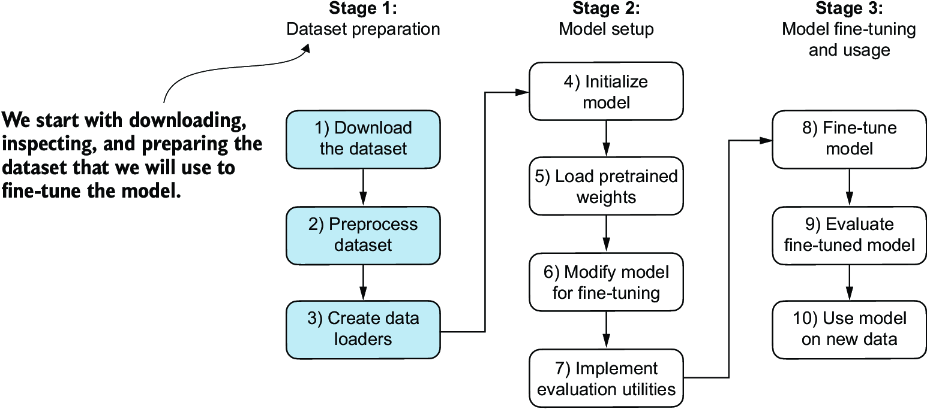

# Stage 1 : Dataset Preparation

## Step 1 : Downloading and unzipping the dataset

In [1]:
import urllib.request
import zipfile
import os
import ssl
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "chapter6/sms_spam_collection.zip"
extracted_path = "chapter6/sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(
        url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
              "and extraction."
        )
        return

    # Create a custom SSL context that doesn't verify certificates
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    
    with urllib.request.urlopen(url, context=ctx) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

chapter6/sms_spam_collection/SMSSpamCollection.tsv already exists. Skipping download and extraction.


## Step 2 : Preprocess Dataset

### Loading into Pandas DataFrame

In [2]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [3]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


### Handling Class Imbalances - Create a Balanced Dataset

In [8]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    )
    balanced_df = pd.concat([
        ham_subset, df[df["Label"] == "spam"]
    ])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


### Convert Class Labels to Binary 0 and 1

In [9]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [10]:
print(balanced_df["Label"].value_counts())

Label
0    747
1    747
Name: count, dtype: int64


### Split the dataset - 70% for training, 10% for validation, and 20% for testing

In [11]:
def random_split(df, train_frac, validation_frac):

    df = df.sample(
        frac=1, random_state=123
    ).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)

### Store data into respective CSV files

In [13]:
train_df.to_csv("chapter6/train.csv", index=None)
validation_df.to_csv("chapter6/validation.csv", index=None)
test_df.to_csv("chapter6/test.csv", index=None)

In [19]:
train_df.head(2)

,Label,Text
0,0,Dude how do you like the buff wind.
1,0,Tessy..pls do me a favor. Pls convey my birthd...


## Step 3 : Create Dataloaders

### Verify token Id for `<|endoftext|>` token

In [14]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


### Setting Pytorch Dataset Class

In [21]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    
    def __init__(self, 
                 csv_file, 
                 tokenizer, 
                 max_length=None,
                 pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length

            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        self.encoded_texts = [
            encoded_text + [pad_token_id] * 
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]
        
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

### Create Dataset - Training, Validation and Test

In [62]:
train_dataset = SpamDataset(
    csv_file="chapter6/train.csv",
    max_length=None,
    tokenizer=tokenizer
)
print("Train Dataset MaxLen: ",train_dataset.max_length)

val_dataset = SpamDataset(
    csv_file="chapter6/validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="chapter6/test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

Train Dataset MaxLen:  120


In [63]:
# Longest Sequence length in the training data
print(test_dataset.max_length)

120


### Create DataLoader - Training, Validation and Test 

In [64]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [65]:
for input_batch, target_batch in train_loader:
    pass # statement is a null operation. It does nothing
    
print("Input batch dimensions:", input_batch.shape) # contains 8 examples with max tokens
print("Label batch dimensions", target_batch.shape) # contains labels

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [66]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


# Checkpoint # 1

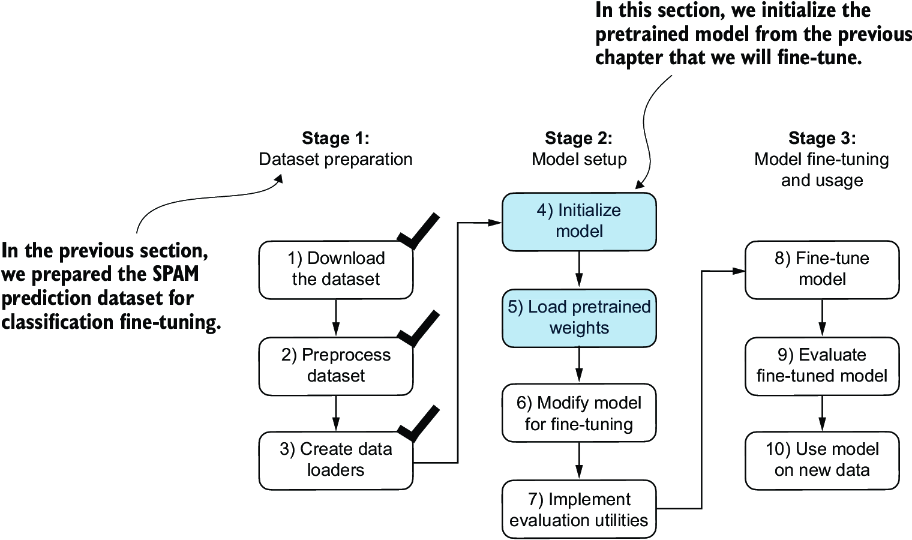

# Stage 2 : Model Setup

## Pre-requisites

### Model Config

In [33]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [68]:
BASE_CONFIG

{'vocab_size': 50257,
 'context_length': 1024,
 'drop_rate': 0.0,
 'qkv_bias': True,
 'emb_dim': 768,
 'n_layers': 12,
 'n_heads': 12}

### Download Pretrained Weigths

In [34]:
import previous_chapters
import importlib
importlib.reload(previous_chapters)

from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size, models_dir="gpt2"
)

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


## Step 4 : Initialize Model

In [35]:
# Initialize GPT Model
model = GPTModel(BASE_CONFIG)

## Step 5 : Load Pretrained Weights

In [36]:
# Loading pretrained weights
load_weights_into_gpt(model, params)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

## Testing the Pretained Model

### Test using the Text Gen utility function

In [37]:
import previous_chapters
import importlib
importlib.reload(previous_chapters)

from previous_chapters import generate_text_simple, text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


### Can a pretrained model classify if prompted with instructions?

In [38]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner


## Step 6 : Modify Model For Fine Tuning 

### Print the model

In [67]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

### Conceptual View

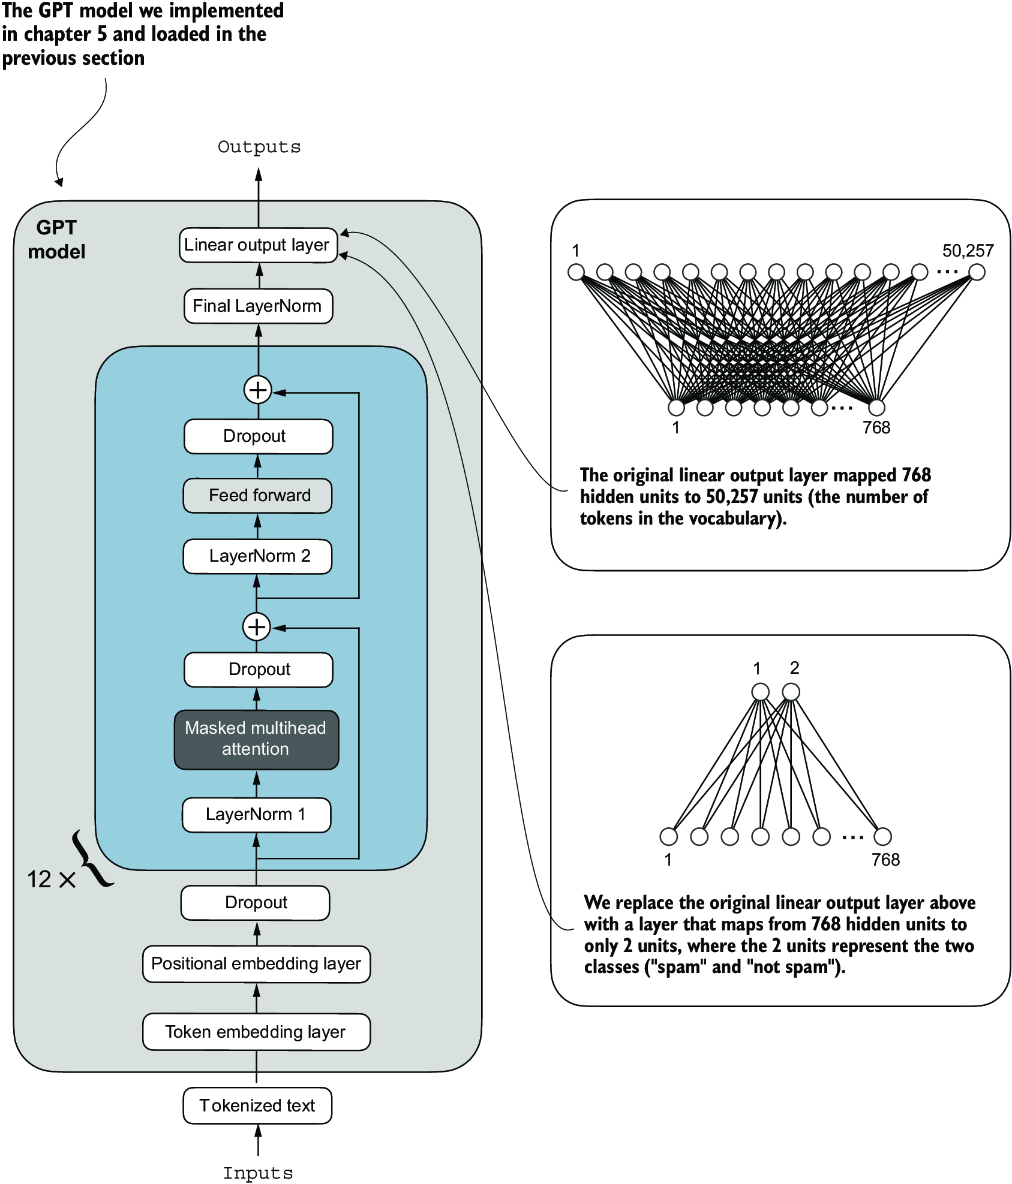

### Adding a Classification Head

#### Freezing the Model (Make all layers non-trainable)

In [40]:
for param in model.parameters():
    param.requires_grad = False

#### Replace the output head

In [41]:
torch.manual_seed(123)
num_classes = 2
# by default this head has requires_grad set to True
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"], 
    out_features=num_classes
)

#### Make `Last Transformer Block` and `LayerNorm` Trainable

In [42]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_norm.parameters():
    param.requires_grad = True

#### Testing the Model

In [43]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [44]:
with torch.no_grad():
    outputs = model(inputs)
print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


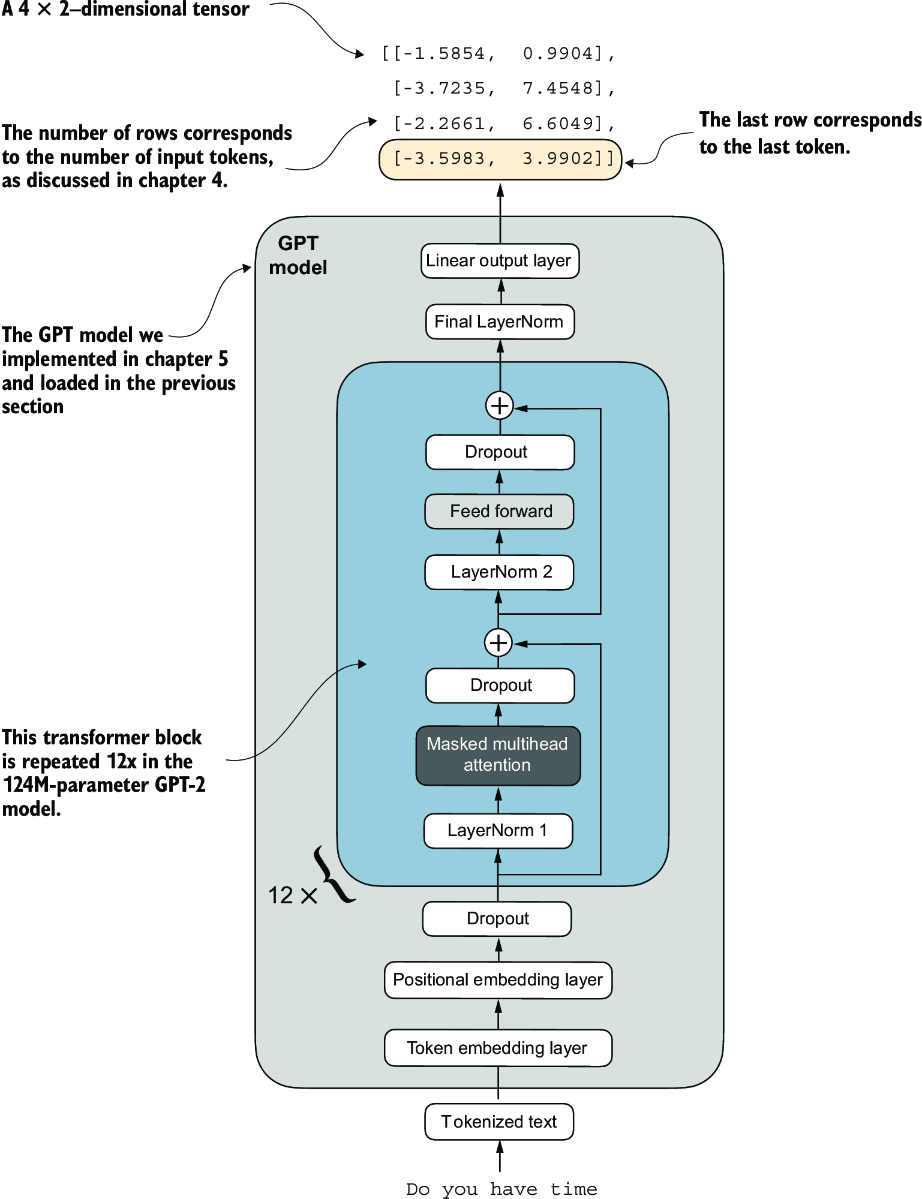

In [45]:
last_output_token = outputs[:, -1, :]
print("Last output token:", last_output_token)

Last output token: tensor([[-3.5983,  3.9902]])


### Convert Model Output to Class Label Prediction

#### Conceptual View

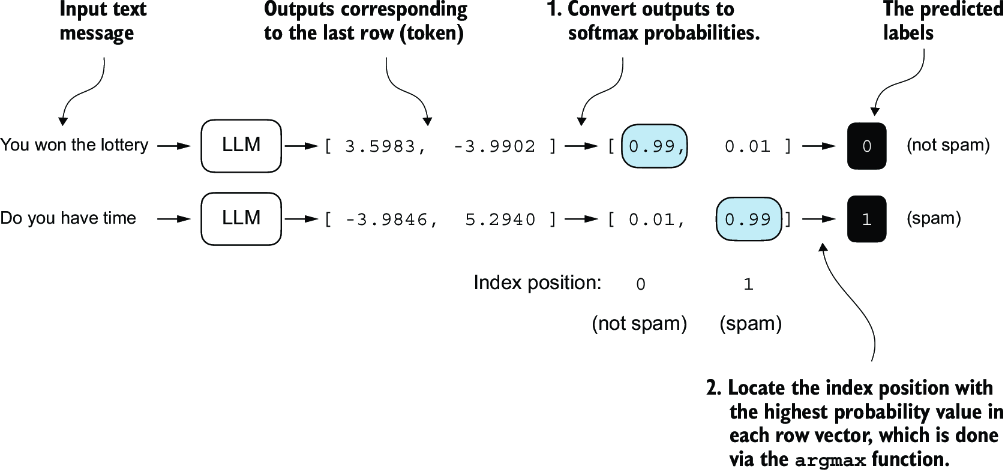

In [46]:
probas = torch.softmax(last_output_token, dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


In [69]:
# largest outputs directly correspond to the highest probability scores
# therefore, softmax is optional

# logits = outputs[:, -1, :]
logits = last_output_token
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


### Checkpoint # 2

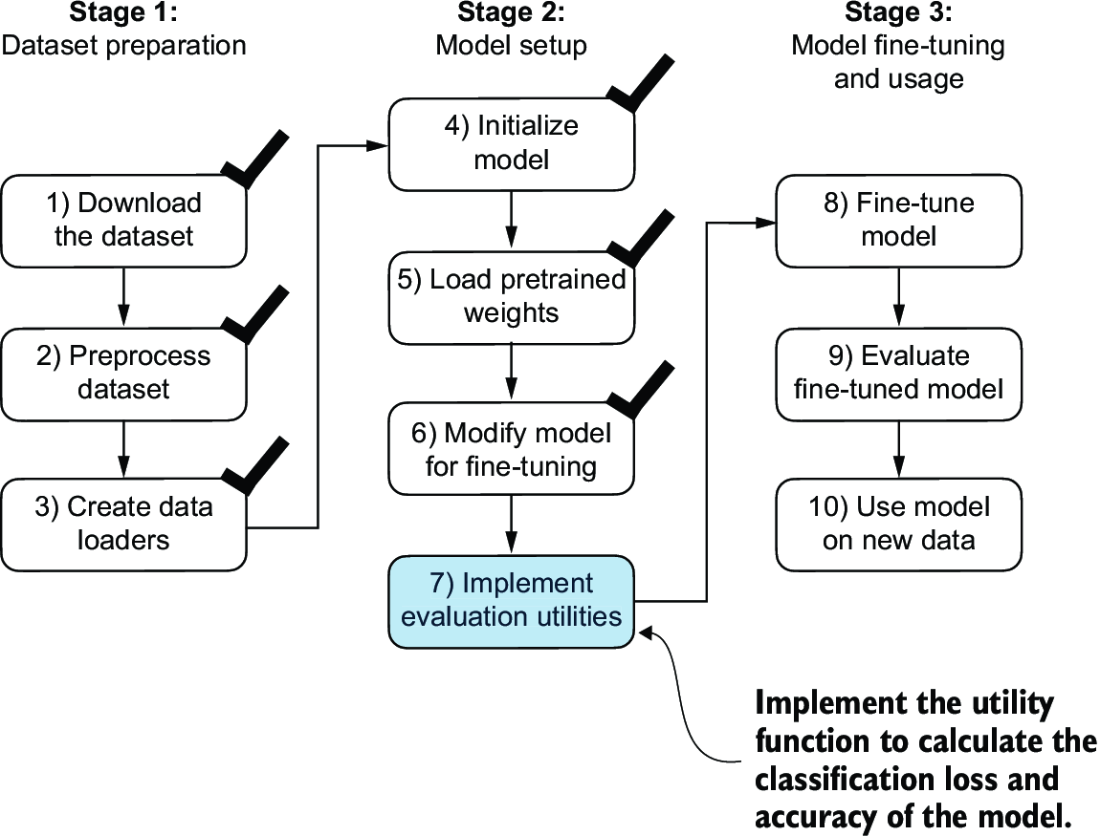

## Step 7 : Implement Evaluation Utilities

**To Calculate Classification Loss and Accuracy of the Model**


### Calculating Classification Accuracy

`Measures the percentage of correct predictions across a dataset.`

In [48]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    
    # set the model to evaluation mode
    # This is important when you want to use your model for inference (making predictions) 
    # rather than training.
    model.eval() 
    
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:

            # move data to device
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (
                (predicted_labels == target_batch).sum().item()
            )

        else:
            break
    return correct_predictions / num_examples

In [74]:
device = torch.device('mps') if torch.backends.mps.is_available() else torch.device("cuda" if torch.cuda.is_available() else "cpu")
# move model to device
model.to(device)
num_batches = 10

torch.manual_seed(123)
train_accuracy = calc_accuracy_loader(
    train_loader, model, device, num_batches=num_batches
)

val_accuracy = calc_accuracy_loader(
    val_loader, model, device, num_batches=num_batches
)

test_accuracy = calc_accuracy_loader(
    test_loader, model, device, num_batches=num_batches
)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 46.25%
Validation accuracy: 45.00%
Test accuracy: 48.75%


### Define Loss Function

In [71]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)[:, -1, :] # last token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

### Calculating Classification Loss

In [72]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [76]:
torch.manual_seed(123)
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.755
Validation loss: 2.310
Test loss: 2.070


# Stage 3 : Fine-Tune Model

## Step 8 : Fine Tune Model

### Conceptual Training Flow

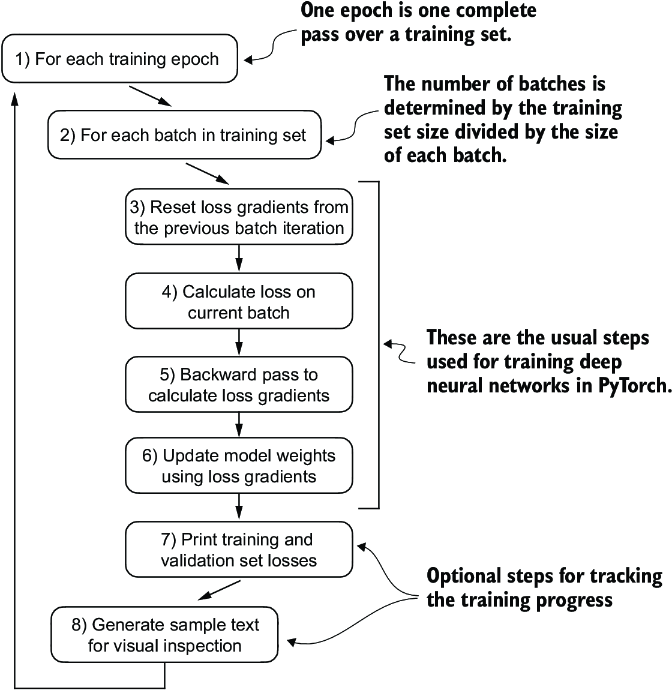

### Define the Training Function

In [77]:
def train_classifier_simple(model, train_loader, val_loader, 
                            optimizer, device, num_epochs, 
                            eval_freq, eval_iter):
    # Variables to track losses, accuracy and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # main training loop
    for epoch in range(num_epochs):
        model.train() # set model in training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # reset loss gradients from prev. batch iterations
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward() # calculate loss gradients
            optimizer.step() # update weights using loss gradients
            examples_seen += input_batch.shape[0] # tracks examples instead of tokens
            global_step += 1

            # Optional Evaluation Step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, "
                      f"Val loss {val_loss:.3f}"
                )

        train_accuracy = calc_accuracy_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_accuracy = calc_accuracy_loader(
            val_loader, model, device, num_batches=eval_iter
        )

        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

### Define the Evaluation Function

In [78]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )
    model.train()
    return train_loss, val_loss

### Initialize the Optimizer, Set the Training Epocs and Initiate the training

In [79]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5
eval_freq = 50
eval_iter = 5

train_losses, val_losses, train_accs, val_accs, examples_seen = \
    train_classifier_simple(
        model, train_loader, val_loader, optimizer, device,
        num_epochs=num_epochs, eval_freq=eval_freq,
        eval_iter=eval_iter
    )

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 1.925, Val loss 2.143
Ep 1 (Step 000050): Train loss 0.615, Val loss 0.635
Ep 1 (Step 000100): Train loss 0.524, Val loss 0.559
Training accuracy: 70.00% | Validation accuracy: 72.50%
Ep 2 (Step 000150): Train loss 0.559, Val loss 0.490
Ep 2 (Step 000200): Train loss 0.415, Val loss 0.397
Ep 2 (Step 000250): Train loss 0.410, Val loss 0.353
Training accuracy: 82.50% | Validation accuracy: 85.00%
Ep 3 (Step 000300): Train loss 0.325, Val loss 0.325
Ep 3 (Step 000350): Train loss 0.345, Val loss 0.315
Training accuracy: 85.00% | Validation accuracy: 85.00%
Ep 4 (Step 000400): Train loss 0.267, Val loss 0.313
Ep 4 (Step 000450): Train loss 0.370, Val loss 0.301
Ep 4 (Step 000500): Train loss 0.338, Val loss 0.331
Training accuracy: 95.00% | Validation accuracy: 85.00%
Ep 5 (Step 000550): Train loss 0.295, Val loss 0.315
Ep 5 (Step 000600): Train loss 0.338, Val loss 0.303
Training accuracy: 95.00% | Validation accuracy: 80.00%
Training completed in 1.06 minu

## Step 9 : Evaluate Fine Tuned Model

### Define the plotting function

In [84]:
import matplotlib.pyplot as plt

def plot_values(
        epochs_seen, examples_seen, train_values, val_values,
        label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))


    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(
        epochs_seen, val_values, linestyle="-.",
        label=f"Validation {label}"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()


    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

### Plot the classification loss

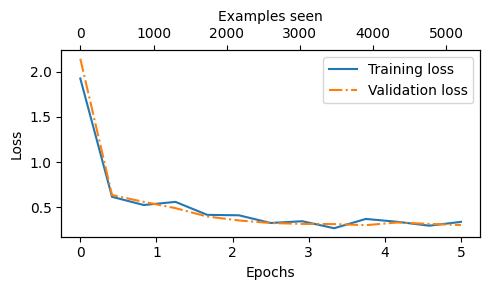

In [85]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

### Plot the classification accuracies

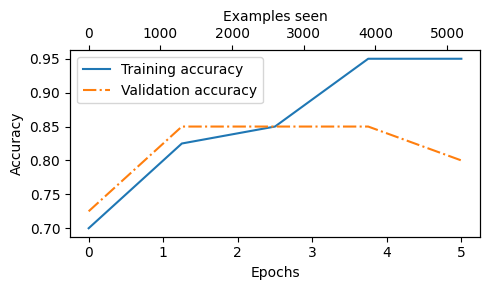

In [86]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(
    epochs_tensor, examples_seen_tensor, train_accs, val_accs,
    label="accuracy"
)

### Calculate the Performance Metrics

In [83]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 91.54%
Validation accuracy: 91.28%
Test accuracy: 93.00%


## Checkpoint # 3

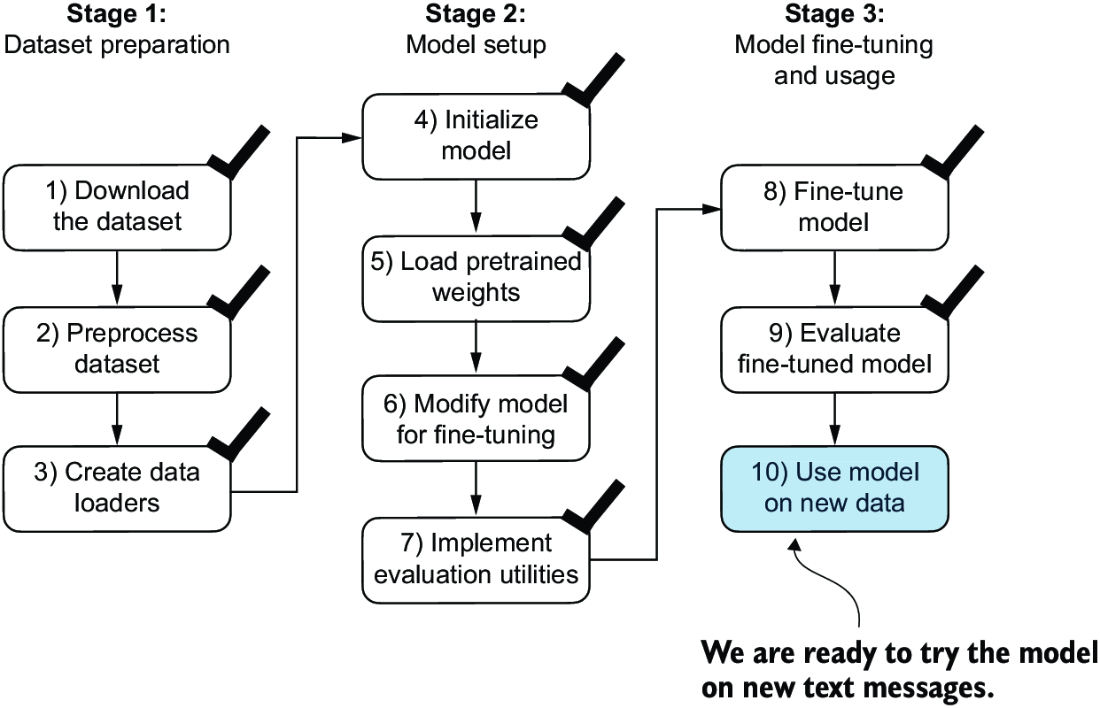

## Step 10 : Use Model on New Data

In [87]:
def classify_review(
        text, model, tokenizer, device, max_length=None,
        pad_token_id=50256):
    model.eval()

    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[1]

    input_ids = input_ids[:min(
        max_length, supported_context_length
    )]

    input_ids += [pad_token_id] * (max_length - len(input_ids))

    input_tensor = torch.tensor(
        input_ids, device=device
    ).unsqueeze(0)

    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"

### Test the model using the text data

In [93]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

text_3 = "Congratulations on unlocking this golden offer. Click the link to redeem it"

text_4 = "Congratulations on unlocking this golden offer. Click the link to redeem it. Immediately."

batch = [text_1, text_2, text_3, text_4]

for item in batch:
    print(classify_review(
        item, model, tokenizer, device, max_length=train_dataset.max_length
    ))

spam
not spam
not spam
spam


## Save the Model

In [94]:
torch.save(model.state_dict(), "chapter6/review_classifier.pth")

## Load the Saved Model

In [95]:
model_state_dict = torch.load("chapter6/review_classifier.pth, map_location=device")
model.load_state_dict(model_state_dict)

/var/folders/5q/988v5vc109g_gdx632gv3qgc0000gp/T/ipykernel_15536/3421770179.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state_dict = torch.load("chapter6/revie

FileNotFoundError: [Errno 2] No such file or directory: 'chapter6/review_classifier.pth, map_location=device'

# Excercises

## Exercise 6.1 - Increasing the context length

`Pad the inputs to the maximum number of tokens the model supports and observe how it affects the predictive performance.`

In [27]:
max_length = 1024

train_dataset = SpamDataset(
    csv_file="chapter6/train.csv",
    max_length=max_length,
    tokenizer=tokenizer
)

val_dataset = SpamDataset(
    csv_file="chapter6/validation.csv",
    max_length=max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="chapter6/test.csv",
    max_length=max_length,
    tokenizer=tokenizer
)

In [28]:
# Longest Sequence length in the training data
print(train_dataset.max_length)

1024


## Exercise 6.2 - Fine-tuning the whole model

`Instead of fine-tuning just the final transformer block, fine-tune the entire model and assess the effect on predictive performance.`

## Exercise 6.3 - Fine-tuning the first vs. last token

`Try fine-tuning the first output token. Notice the changes in predictive performance compared to fine-tuning the last output token.`